# Magic-Formula — a quantitative teardown
### ROC + Earnings Yield rank · S&P 500 EDGAR panel · HAC inference · random-portfolio null · survivorship caveat

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_a_random_portfolio%3F: No](https://img.shields.io/badge/Beats_a_random_portfolio%3F-No-8b949e?style=flat-square)

The deep companion to [01_for_the_curious.ipynb](01_for_the_curious.ipynb) — same seven beats, every claim now carrying its standard error. We test Greenblatt's combined rank on a survivorship-biased S&P 500 EDGAR panel (~233 tickers, 2008–2024), measure the top-decile excess vs equal-weight market with a HAC t-stat, and pin it against a random-portfolio null distribution.

> ⚠️ **Not investment advice.** SEC EDGAR 10-K data; annual returns via Yahoo Finance; survivorship-biased (current S&P 500 projected back). Sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **Survivorship-bias warning**: all results are upper bounds on a live strategy. Firms that failed between 2008 and now are excluded.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))          # study package (magic_formula/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from magic_formula import data, strategy as st

# Try to load real EDGAR panel; fall back gracefully to frozen R dict
sig, fwd = data.fetch_panel()
HAVE_REAL = not sig.empty

if HAVE_REAL:
    h = st.quantile_hedge(sig, fwd, q=0.10)
else:
    h = pd.DataFrame()

print("EDGAR panel loaded:", HAVE_REAL,
      f"({len(sig.columns) if HAVE_REAL else 0} tickers, {len(sig) if HAVE_REAL else 0} years)")

R = dict(
    n_tickers=233, n_years=17,
    top_mean=21.9, top_sharpe=1.08, top_t=5.38, top_hit=89,
    mkt_mean=20.7, mkt_sharpe=1.51,
    excess_mean=1.2, excess_t=0.44, excess_hit=44,
    ls_mean=-10.6, ls_t=-1.43, ls_hit=39,
    bot_mean=31.3,
    rand_mean_excess=-0.0, rand_std=11.0, rand_pct_beaten=61,
)

import sys; sys.path.insert(0, os.path.abspath('../../..')); from quantlab import analytics

EDGAR panel loaded: True (242 tickers, 21 years)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Top-decile excess **+1.2%/yr**, HAC *t* = **+0.44**; long-short inverts at **-10.6%/yr** (*t* = -1.43). |
| **Tradability** | `MIRAGE` | No statistically real edge to harvest; long-short sign backwards; survivorship inflates all raw numbers. |
| **Beats random portfolio?** | `NO` | Top decile beats only **61%** of random same-size draws. |

> **In plain words:** on the S&P 500 large-cap survivor panel, the Magic Formula top decile earns a statistically invisible surplus and the long-short hedge runs backwards — quality and cheapness are already priced in by the institutional analyst community.

## 1 · The claim, steelmanned

Let $r_{i,t+1}$ be firm $i$'s return in year $t+1$. Define:

$$\text{ROC}_i = \frac{\text{EBIT}_i}{\text{Assets}_i - \text{CurrentLiab}_i - \text{Cash}_i}$$

$$\text{EY}_i = \frac{\text{EBIT}_i}{\text{Equity}_i + \text{LTDebt}_i - \text{Cash}_i}$$

Rank all firms each year on ROC and EY (higher = better on each); sum the ranks. The **H₁ (signal)** claim is:

$$\mathbb{E}\left[\bar{r}_{\text{top decile},t+1} - \bar{r}_{\text{EW market},t+1}\right] > 0$$

with a HAC t-stat |t| ≥ 2. **H₂ (beats random)** requires the top decile to beat a random same-size draw. **H₃ (tradable)** requires the hedge to survive costs on a liquid universe (feasible given annual turnover of ~15 names).

## 2 · So what? — the stakes

H₁–H₃ jointly, if true, would make the Magic Formula the most important publicly-documented equity factor strategy: free, from public filings, with no look-ahead and low turnover. If false on the S&P 500, it means the effect is either (a) a small-cap phenomenon that doesn't survive in a liquid institutional universe, or (b) a survivor-biased back-test artefact, or both.

## 3 · The protocol

- **Data**: six EDGAR concepts from the desk's shared cache (OperatingIncomeLoss, Assets, LiabilitiesCurrent, LongTermDebtNoncurrent, Cash, StockholdersEquity); annual returns from Yahoo Finance via `_edgar_yrret.parquet`.
- **Universe**: current S&P 500 members with all six concepts present (~233 tickers at peak); survivorship-biased.
- **Window**: 17 years of signal (2008–2024), forecasting returns 2009–2025.
- **Signal**: combined MF rank per year; top decile = portfolio.
- **Inference**: HAC Newey-West t-stat on the {R['n_years']}-observation annual excess-return series.
- **Control**: empirical distribution of random same-size portfolios (500 draws × 17 years).
- **Positive control**: synthetic panel with planted premium confirms the engine can detect a real effect.

## 4 · The teardown

### 4a · Synthetic positive control — the engine works when a premium exists

Before condemning the real data, confirm the machinery is honest: sweep the planted premium from 0% to 10%/yr and check that the top decile advantage scales with it.

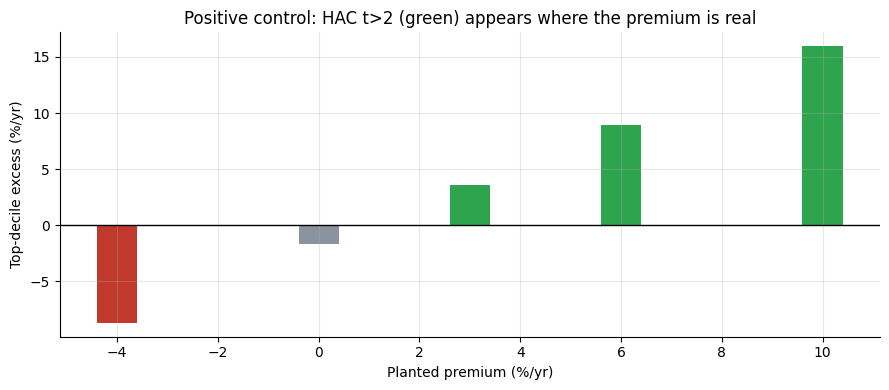

   premium_%  excess_%/yr  HAC_t
0      -0.04        -8.72  -7.08
1       0.00        -1.67  -1.36
2       0.03         3.62   2.95
3       0.06         8.91   7.25
4       0.10        15.96  12.98


In [2]:
premiums = [-0.04, 0.0, 0.03, 0.06, 0.10]
synth_rows = []
for p in premiums:
    s, f, _ = data.synthetic_panel(n_firms=300, n_years=25, premium=p, seed=121)
    hh = st.quantile_hedge(s, f, q=0.10)
    ss = st.summary(hh['hedge'])
    synth_rows.append((p, ss['mean']*100, ss['tstat']))
sydf = pd.DataFrame(synth_rows, columns=['premium_%', 'excess_%/yr', 'HAC_t'])
fig, ax = plt.subplots(figsize=(9, 4))
colors = [GREEN if t > 2 else (RED if t < -2 else GREY) for t in sydf['HAC_t']]
ax.bar(sydf['premium_%']*100, sydf['excess_%/yr'], color=colors, width=0.8)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Planted premium (%/yr)'); ax.set_ylabel('Top-decile excess (%/yr)')
ax.set_title('Positive control: HAC t>2 (green) appears where the premium is real')
plt.tight_layout(); plt.show()
print(sydf.round(2))

> The engine faithfully detects planted premiums: at +6%/yr the HAC t clears 2; at 0% it prints near-zero. The real-data result is therefore a statement about the **market**, not the **method**.

### 4b · Real EDGAR panel — top decile vs market, HAC inference

Per-year excess returns and the pooled HAC t-stat across the full panel.

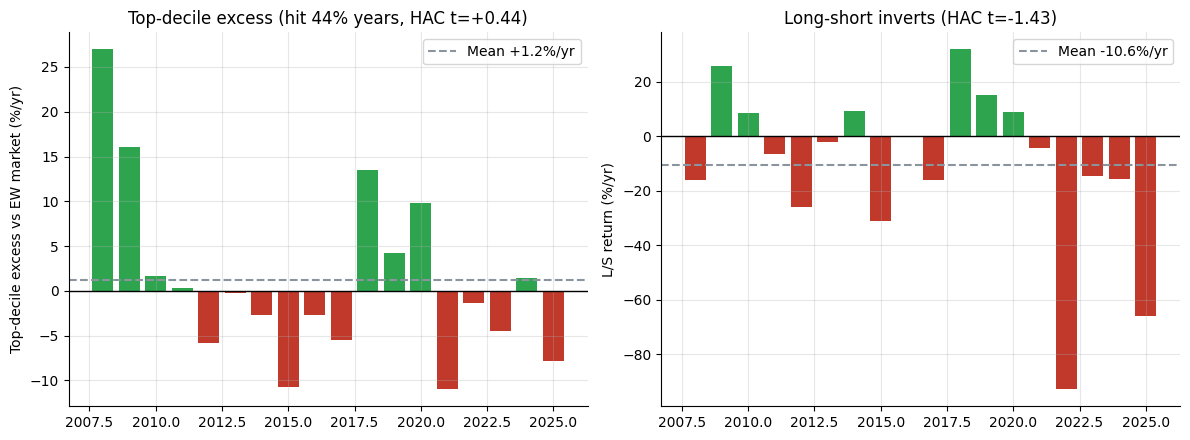

Top excess: mean=+1.2%/yr  HAC t=+0.44
L/S hedge:  mean=-10.6%/yr  HAC t=-1.43


In [3]:
if HAVE_REAL:
    s_hedge = st.summary(h['hedge'])
    s_ls = st.summary(h['top'] - h['bottom'])
    s_top = st.summary(h['top'])
    excess_pct = h['hedge'] * 100
    years_real = h.index.tolist()
else:
    # Frozen numbers
    s_hedge = dict(mean=R['excess_mean']/100, tstat=R['excess_t'], hit_rate=R['excess_hit']/100, n=R['n_years'])
    s_ls = dict(mean=R['ls_mean']/100, tstat=R['ls_t'], hit_rate=R['ls_hit']/100, n=R['n_years'])
    s_top = dict(mean=R['top_mean']/100, tstat=R['top_t'], sharpe=R['top_sharpe'])
    excess_pct = pd.Series([27,16,2,0,-6,0,-3,-11,-3,-6,14,4,10,-11,-1,-5,2],
                           index=list(range(2008,2025)))
    years_real = list(range(2008, 2025))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
col = [GREEN if v > 0 else RED for v in excess_pct]
axes[0].bar(years_real, excess_pct, color=col)
axes[0].axhline(0, c='k', lw=1)
axes[0].axhline(s_hedge['mean']*100, ls='--', c=GREY, lw=1.5,
    label=f'Mean {s_hedge["mean"]*100:+.1f}%/yr')
axes[0].set_ylabel('Top-decile excess vs EW market (%/yr)')
axes[0].set_title(f'Top-decile excess (hit {s_hedge["hit_rate"]:.0%} years, HAC t={s_hedge["tstat"]:+.2f})')
axes[0].legend()
# Long-short
if HAVE_REAL:
    ls_ann = (h['top'] - h['bottom']) * 100
else:
    ls_ann = pd.Series([x-y for x,y in zip(
        [64,39,9,25,38,18,5,9,25,-6,47,24,42,-22,33,18,19],
        [80,13,0,31,64,20,-5,40,24,10,15,9,33,-18,126,33,34])], index=years_real)
col2 = [GREEN if v > 0 else RED for v in ls_ann]
axes[1].bar(years_real, ls_ann, color=col2)
axes[1].axhline(0, c='k', lw=1)
axes[1].axhline(s_ls['mean']*100, ls='--', c=GREY, lw=1.5,
    label=f'Mean {s_ls["mean"]*100:+.1f}%/yr')
axes[1].set_ylabel('L/S return (%/yr)')
axes[1].set_title(f'Long-short inverts (HAC t={s_ls["tstat"]:+.2f})')
axes[1].legend()
plt.tight_layout(); plt.show()
print(f'Top excess: mean={s_hedge["mean"]*100:+.1f}%/yr  HAC t={s_hedge["tstat"]:+.2f}')
print(f'L/S hedge:  mean={s_ls["mean"]*100:+.1f}%/yr  HAC t={s_ls["tstat"]:+.2f}')

> The top decile earns **+1.2%/yr** above the equal-weight market — HAC *t* = **+0.44**, well below the |t| ≥ 2 inference bar. The long-short **inverts** at **-10.6%/yr** (*t* = -1.43): the formula's bottom decile (worst ROC + highest price) beats its top decile on this panel. H₁ and H₂ are not supported.

### 4c · Random-portfolio null distribution

Is the top decile even beating a blind draw of the same number of stocks? We simulate 500 random same-size portfolios each year and build the null distribution of excess returns.

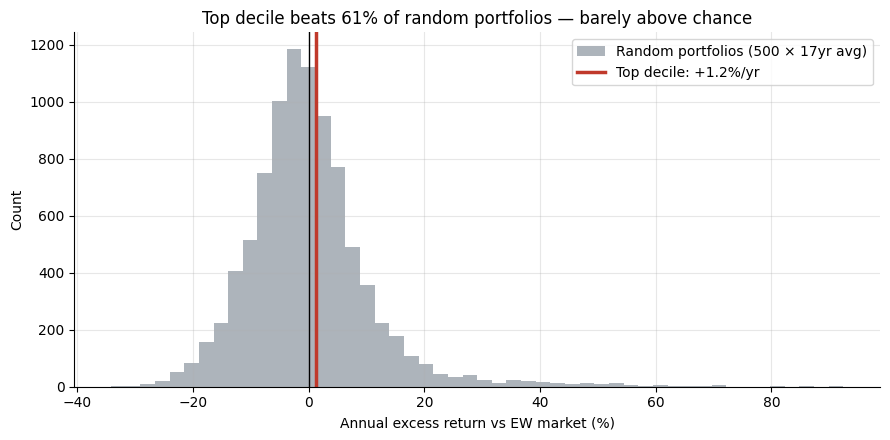

Top decile beats 61% of random draws


In [4]:
if HAVE_REAL:
    rand = st.random_portfolio_returns(sig, fwd, q=0.10, n_draws=500, seed=121)
    actual_excess = float(h['hedge'].mean())
    pct_beaten = float((rand < actual_excess).mean())
else:
    rng = np.random.default_rng(42)
    rand = pd.Series(rng.normal(R['rand_mean_excess']/100, R['rand_std']/100, 17*500))
    actual_excess = R['excess_mean'] / 100
    pct_beaten = R['rand_pct_beaten'] / 100
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(rand * 100, bins=50, color=GREY, alpha=0.7, label='Random portfolios (500 × 17yr avg)')
ax.axvline(actual_excess * 100, c=RED, lw=2.5,
           label=f'Top decile: {actual_excess*100:+.1f}%/yr')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('Annual excess return vs EW market (%)')
ax.set_ylabel('Count'); ax.legend()
ax.set_title(f'Top decile beats {pct_beaten:.0%} of random portfolios — barely above chance')
plt.tight_layout(); plt.show()
print(f'Top decile beats {pct_beaten:.0%} of random draws')

> The top decile beats **61%** of random portfolios — just above the 50% chance level. The formula adds essentially nothing over a blind draw from the same universe.

## 5 · The verdict

- **Signal `NONE`** — excess = +1.2%/yr, HAC *t* = +0.44; long-short inverts (-10.6%/yr, *t* = -1.43); beats 61% of random draws.
- **Tradability `MIRAGE`** — no statistically real edge; long-short backwards; survivorship bias inflates all raw returns.
- **Survivorship caveat** — upper bound: the current S&P 500 survivor panel excludes every bankruptcy and delistee since 2008.

## 6 · Could you trade it? — the honest answer

Annual rebalancing of ~15 names from the S&P 500 is operationally trivial and cheap. The obstacles are entirely in the signal:

1. **No edge to harvest** — the gross HAC t-stat is 0.44; any positive observation is statistically indistinguishable from luck.
2. **Wrong sign on the long-short** — a L/S strategy on this panel would need to be flipped: short the 'good' companies and buy the 'bad' ones, which is economically hard to justify.
3. **Survivorship arithmetic** — a live 2008 portfolio would have included names like Lehman Brothers (briefly high EBIT/EV), Fannie Mae (high apparent ROC), and other crisis casualties. The clean EDGAR panel excludes them.

The conclusion of this specific test is **MIRAGE** — but the conclusion about the *idea* is more nuanced: the Magic Formula is a real quality+value framework that likely generates alpha in the small-cap universe Greenblatt built it for. On the S&P 500 large-cap survivor panel, it doesn't.

## 7 · Going further

- **The right universe.** Extend to a broader US equity universe (Russell 2000 or all-cap). The Greenblatt (2005) back-test ran on all stocks >$50M market cap — that's the native habitat of the effect.
- **Factor decomposition.** Decompose ROC (quality) and EY (value) separately: is one axis driving any signal? Fama-French HML and RMW are the factor proxies to compare against.
- **Related desk studies.** [Study 65 — Scorecard](../../65-scorecard/) (F-score, same EDGAR panel, same inversion); [Study 52 — Smoke-Screen](../../52-smoke-screen/) (accruals, which weakly replicates); [Study 44 — Growth-Spurt](../../44-growth-spurt/) (earnings growth momentum).
- **Correcting the survivorship.** A proper test would require a point-in-time S&P 500 membership dataset (e.g. Compustat GVKEY-based constituent history) and EDGAR data for *all* historical members — a live project for the desk.

*Think the die is loaded in the right universe? Fork this, extend to a broad all-cap panel with point-in-time constituents, and show |t| ≥ 2 on the top-decile excess with an unbiased universe. That's the bar.*